In [1]:
# Pytorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
!pip install torchinfo
from torchinfo import summary
# Helper libraries
import numpy as np
import matplotlib.pyplot as plt

# 1. 데이터 준비
- torchvision.datasets의 OxfordIIIYPet 데이터셋 사용

In [15]:
import torch
import torchvision
import torchvision.transforms as transforms

# 데이터를 저장할 위치
data_root = "/content/data"

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Train
trainset = torchvision.datasets.OxfordIIITPet(
    root=data_root,
    split="trainval",
    target_types="category",
    download=True,
    transform=transform
)

# Test
testset = torchvision.datasets.OxfordIIITPet(
    root=data_root,
    split="test",
    target_types="category",
    download=True,
    transform=transform
)

trainloader = torch.utils.data.DataLoader(
    trainset,
    batch_size=32,
    shuffle=True
)

testloader = torch.utils.data.DataLoader(
    testset,
    batch_size=32,
    shuffle=False
)

100%|██████████| 792M/792M [00:29<00:00, 27.2MB/s]
100%|██████████| 19.2M/19.2M [00:01<00:00, 13.4MB/s]


# 2. 데이터 확인하기

In [16]:
image, label = trainset[0]

print(f"Image shape: {image.shape}")
print(f"Label: {label}")
print(f"Number of classes: {len(trainset.classes)}")
print(trainset.classes)
print('\n')

train_size = torch.tensor(len(trainset))
test_size = torch.tensor(len(testset))

print(f"Train dataset size: {train_size} (Shape: {train_size.shape})")
print(f"Test dataset size: {test_size} (Shape: {test_size.shape})")

Image shape: torch.Size([3, 224, 224])
Label: 0
Number of classes: 37
['Abyssinian', 'American Bulldog', 'American Pit Bull Terrier', 'Basset Hound', 'Beagle', 'Bengal', 'Birman', 'Bombay', 'Boxer', 'British Shorthair', 'Chihuahua', 'Egyptian Mau', 'English Cocker Spaniel', 'English Setter', 'German Shorthaired', 'Great Pyrenees', 'Havanese', 'Japanese Chin', 'Keeshond', 'Leonberger', 'Maine Coon', 'Miniature Pinscher', 'Newfoundland', 'Persian', 'Pomeranian', 'Pug', 'Ragdoll', 'Russian Blue', 'Saint Bernard', 'Samoyed', 'Scottish Terrier', 'Shiba Inu', 'Siamese', 'Sphynx', 'Staffordshire Bull Terrier', 'Wheaten Terrier', 'Yorkshire Terrier']


Train dataset size: 3680 (Shape: torch.Size([]))
Test dataset size: 3669 (Shape: torch.Size([]))


In [17]:
def imshow(img):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    img = img * std + mean
    img = img.clamp(0, 1)

    npimg = img.numpy()
    return np.transpose(npimg, (1, 2, 0))

def show_multiple_images(dataloader, n_images=9):
    dataiter = iter(dataloader)
    images, labels = next(dataiter)

    fig, axes = plt.subplots(3, 3, figsize=(6, 6))
    axes = axes.flatten()

    for i in range(n_images):
        axes[i].imshow(imshow(images[i]))
        axes[i].set_title(trainset.classes[labels[i]])
        axes[i].axis("off")

    plt.tight_layout()
    plt.show()

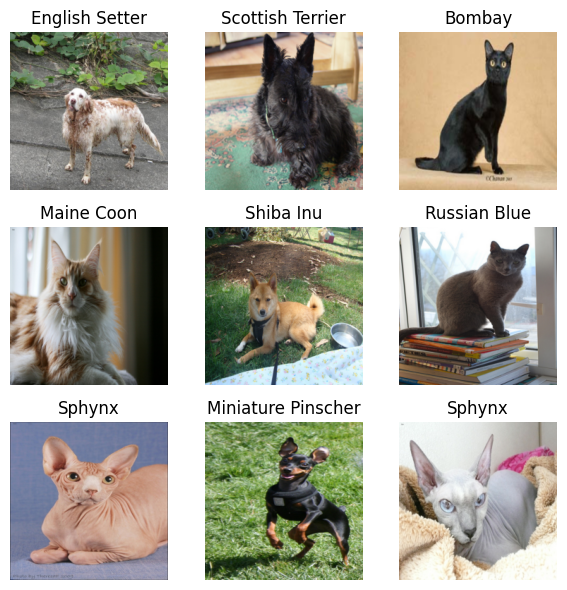

In [18]:
# 학습 데이터셋에서 9개의 이미지를 시각화
show_multiple_images(trainloader)

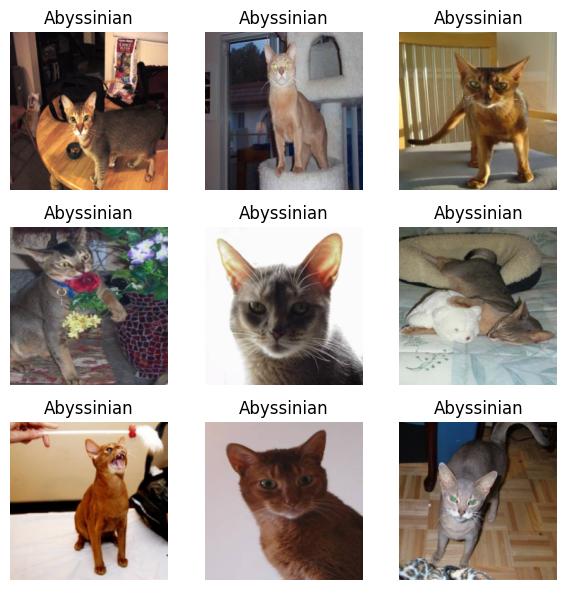

In [19]:
# 테스트 데이터셋에서 9개의 이미지를 시각화
show_multiple_images(testloader)

# 3. ResNet34, ResNet50, Plain34, Plain50 구현하기
- ResNet이라는 공통 클래스
- 모델마다 블록 구성에 차이가 있기 때문에 각 블록을 위한 클래스를 별도로 작성

In [39]:
# ResNet
#   ├─ block_type = Bottleneck        → ResNet50
#   ├─ block_type = BasicBlock        → ResNet34
#   ├─ block_type = PlainBottleneck   → Plain50
#   └─ block_type = PlainBasicBlock   → Plain34

### ResNet50

In [20]:
# ResNet Bottleneck 블록 (ResNet50에서 사용)
# 입력 → [1x1 conv 축소] → [3x3 conv] → [1x1 conv 확장] → (+입력) → 출력

class Bottleneck(nn.Module):
    expansion = 4  # 출력 채널 = mid_channels * expansion

    def __init__(self, in_channels, mid_channels, stride=1, downsample=None):
        super(Bottleneck, self).__init__()

        out_channels = mid_channels * self.expansion

        # 1x1 conv (채널 축소)
        self.conv1 = nn.Conv2d(in_channels, mid_channels, kernel_size=1, bias=False)
        self.bn1 = nn.BatchNorm2d(mid_channels)

        # 3x3 conv (특징 추출, stride 여기서 적용)
        self.conv2 = nn.Conv2d(mid_channels, mid_channels, kernel_size=3,
                                stride=stride, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(mid_channels)

        # 1x1 conv (채널 확장)
        self.conv3 = nn.Conv2d(mid_channels, out_channels, kernel_size=1, bias=False)
        self.bn3 = nn.BatchNorm2d(out_channels)

        self.relu = nn.ReLU(inplace=True)

        # 입출력 shape이 다를 때 맞춰주는 downsample (layer 마다 첫 블록에만 존재)
        self.downsample = downsample
        self.stride = stride

    def forward(self, x):
        identity = x  # skip connection용 원본 입력 저장

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)

        out = self.conv3(out)
        out = self.bn3(out)

        # 입력 채널 크기가 다르면 downsample로 맞춰줌
        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity                # residual connection
        out = self.relu(out)

        return out

### ResNet34

In [21]:
# ResNet34에서 사용
# 입력 → [3x3 conv] → [3x3 conv] → (+입력) → 출력

class BasicBlock(nn.Module):
    expansion = 1  # Bottleneck과 달리 채널을 확장하지 않음

    def __init__(self, in_channels, mid_channels, stride=1, downsample=None):
        super(BasicBlock, self).__init__()

        out_channels = mid_channels * self.expansion

        # 3x3 conv (첫 번째, stride 여기서 적용)
        self.conv1 = nn.Conv2d(in_channels, mid_channels, kernel_size=3,
                                stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(mid_channels)

        # 3x3 conv (두 번째)
        self.conv2 = nn.Conv2d(mid_channels, out_channels, kernel_size=3,
                                stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.relu = nn.ReLU(inplace=True)

        # 입출력 shape이 다를 때 맞춰주는 downsample
        self.downsample = downsample
        self.stride = stride

    def forward(self, x):
        identity = x  # skip connection

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        # 입력 채널 크기가 다르면 downsample로 맞춰줌
        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity                # residual connection
        out = self.relu(out)

        return out

### Plain50

In [22]:
# Plain Bottleneck 블록
# 입력 → [1x1 conv 축소] → [3x3 conv] → [1x1 conv 확장] → 출력

class PlainBottleneck(nn.Module):
    expansion = 4  # Bottleneck과 동일

    def __init__(self, in_channels, mid_channels, stride=1, downsample=None):
        super(PlainBottleneck, self).__init__()

        out_channels = mid_channels * self.expansion

        # 1x1 conv (채널 축소)
        self.conv1 = nn.Conv2d(in_channels, mid_channels, kernel_size=1, bias=False)
        self.bn1 = nn.BatchNorm2d(mid_channels)

        # 3x3 conv (특징 추출, stride 여기서 적용)
        self.conv2 = nn.Conv2d(mid_channels, mid_channels, kernel_size=3,
                                stride=stride, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(mid_channels)

        # 1x1 conv (채널 확장)
        self.conv3 = nn.Conv2d(mid_channels, out_channels, kernel_size=1, bias=False)
        self.bn3 = nn.BatchNorm2d(out_channels)

        self.relu = nn.ReLU(inplace=True)

        # downsample은 받지만 실제로 사용하지 않음
        self.downsample = downsample
        self.stride = stride

    def forward(self, x):
        # identity를 저장하지 않음 (skip connection 없음)

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)

        out = self.conv3(out)
        out = self.bn3(out)

        out = self.relu(out)

        return out

### Plain34

In [24]:
# Plain BasicBlock
# 입력 → [3x3 conv] → [3x3 conv] → 출력

class PlainBasicBlock(nn.Module):
    expansion = 1  # BasicBlock과 동일

    def __init__(self, in_channels, mid_channels, stride=1, downsample=None):
        super(PlainBasicBlock, self).__init__()

        out_channels = mid_channels * self.expansion

        # 3x3 conv (첫 번째, stride 여기서 적용)
        self.conv1 = nn.Conv2d(in_channels, mid_channels, kernel_size=3,
                                stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(mid_channels)

        # 3x3 conv (두 번째)
        self.conv2 = nn.Conv2d(mid_channels, out_channels, kernel_size=3,
                                stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.relu = nn.ReLU(inplace=True)

        # downsample은 받지만 실제로 사용하지 않음
        self.downsample = downsample
        self.stride = stride

    def forward(self, x):
        # identity를 저장하지 않음 (skip connection 없음)

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        out = self.relu(out)

        return out

### ResNet 공통 클래스

In [23]:
# ResNet 전체 모델

# 입력 이미지 (3, 224, 224)
#     │
#     ▼
# [Stem]  conv1(7x7) → bn1 → relu → maxpool
#     │   (이미지 크기: 224 → 56)
#     ▼
# [layer1]  block 3개 (출력 채널 64 or 256, 해상도 56 유지)
#     ▼
# [layer2]  block 4개 (출력 채널 2배, 해상도 절반 → 28)
#     ▼
# [layer3]  block 6개 (출력 채널 2배, 해상도 절반 → 14)
#     ▼
# [layer4]  block 3개 (출력 채널 2배, 해상도 절반 → 7)
#     ▼
# [avgpool]  (7,7) 크기의 feature map을 (1,1)로 평균
#     ▼
# [flatten]  1차원으로 펼치기
#     ▼
# [fc]  Linear로 클래스 개수만큼 출력

class ResNet(nn.Module):
    def __init__(self,
                 block_type,
                 num_blocks_list=[3, 4, 6, 3],
                 channel_list=[64, 128, 256, 512],
                 num_classes=1000):
        super(ResNet, self).__init__()

        assert len(num_blocks_list) == len(channel_list), "num_blocks_list와 channel_list의 길이가 일치해야 합니다."

        self.in_channels = 64

        # Stem: 7x7 conv + bn + relu + maxpool
        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        # layer1~layer4
        self.layer1 = self._make_layer(block_type, channel_list[0], num_blocks_list[0], stride=1)
        self.layer2 = self._make_layer(block_type, channel_list[1], num_blocks_list[1], stride=2)
        self.layer3 = self._make_layer(block_type, channel_list[2], num_blocks_list[2], stride=2)
        self.layer4 = self._make_layer(block_type, channel_list[3], num_blocks_list[3], stride=2)

        # 분류기
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))  # GAP 사용
        self.fc = nn.Linear(channel_list[-1] * block_type.expansion, num_classes)

    # 한 layer 생성
    def _make_layer(self, block_type, mid_channels, num_blocks, stride):
        downsample = None
        out_channels = mid_channels * block_type.expansion

        # 채널 수나 크기가 바뀌는 경우 downsample 필요 (각 layer의 첫 블록에만 생성)
        if stride != 1 or self.in_channels != out_channels:
            downsample = nn.Sequential(
                nn.Conv2d(self.in_channels, out_channels, kernel_size=1,
                          stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

        # 첫 번째 블록 (stride, downsample 적용)
        layers = [block_type(self.in_channels, mid_channels, stride, downsample)]
        self.in_channels = out_channels

        # 나머지 블록 추가 (stride=1, downsample 없음)
        for _ in range(num_blocks - 1):
            layers.append(block_type(self.in_channels, mid_channels))

        return nn.Sequential(*layers)

    def forward(self, x):
        # Stem
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        # Residual layers
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        # 분류기
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)

        return x

### 모델 생성

In [25]:
# ResNet34 생성 함수
def build_resnet34(num_classes=1000):
    return ResNet(block_type=BasicBlock,
                  num_blocks_list=[3, 4, 6, 3],
                  channel_list=[64, 128, 256, 512],
                  num_classes=num_classes)

In [26]:
# 모델 생성 및 확인
resnet_34 = build_resnet34(num_classes=1000)
summary(resnet_34, input_size=(1, 3, 224, 224))

Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [1, 1000]                 --
├─Conv2d: 1-1                            [1, 64, 112, 112]         9,408
├─BatchNorm2d: 1-2                       [1, 64, 112, 112]         128
├─ReLU: 1-3                              [1, 64, 112, 112]         --
├─MaxPool2d: 1-4                         [1, 64, 56, 56]           --
├─Sequential: 1-5                        [1, 64, 56, 56]           --
│    └─BasicBlock: 2-1                   [1, 64, 56, 56]           --
│    │    └─Conv2d: 3-1                  [1, 64, 56, 56]           36,864
│    │    └─BatchNorm2d: 3-2             [1, 64, 56, 56]           128
│    │    └─ReLU: 3-3                    [1, 64, 56, 56]           --
│    │    └─Conv2d: 3-4                  [1, 64, 56, 56]           36,864
│    │    └─BatchNorm2d: 3-5             [1, 64, 56, 56]           128
│    │    └─ReLU: 3-6                    [1, 64, 56, 56]           --
│

In [27]:
# ResNet50 생성 함수
def build_resnet50(num_classes=1000):
    return ResNet(block_type=Bottleneck,
                  num_blocks_list=[3, 4, 6, 3],
                  channel_list=[64, 128, 256, 512],
                  num_classes=num_classes)

In [28]:
# 모델 생성 및 확인
resnet_50 = build_resnet50()
summary(resnet_50, input_size=(1, 3, 224, 224))

Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [1, 1000]                 --
├─Conv2d: 1-1                            [1, 64, 112, 112]         9,408
├─BatchNorm2d: 1-2                       [1, 64, 112, 112]         128
├─ReLU: 1-3                              [1, 64, 112, 112]         --
├─MaxPool2d: 1-4                         [1, 64, 56, 56]           --
├─Sequential: 1-5                        [1, 256, 56, 56]          --
│    └─Bottleneck: 2-1                   [1, 256, 56, 56]          --
│    │    └─Conv2d: 3-1                  [1, 64, 56, 56]           4,096
│    │    └─BatchNorm2d: 3-2             [1, 64, 56, 56]           128
│    │    └─ReLU: 3-3                    [1, 64, 56, 56]           --
│    │    └─Conv2d: 3-4                  [1, 64, 56, 56]           36,864
│    │    └─BatchNorm2d: 3-5             [1, 64, 56, 56]           128
│    │    └─ReLU: 3-6                    [1, 64, 56, 56]           --
│ 

In [29]:
# Plain-34 생성 함수
def build_plain34(num_classes=1000):
    return ResNet(block_type=PlainBasicBlock,
                  num_blocks_list=[3, 4, 6, 3],
                  channel_list=[64, 128, 256, 512],
                  num_classes=num_classes)

In [30]:
# Plain-50 생성 함수
def build_plain50(num_classes=1000):
    return ResNet(block_type=PlainBottleneck,
                  num_blocks_list=[3, 4, 6, 3],
                  channel_list=[64, 128, 256, 512],
                  num_classes=num_classes)

# 4. 학습하기

### ResNet34

In [31]:
BATCH_SIZE = 32
EPOCH = 15
import time

# 학습 시작 시간 저장
current_time = time.time()

# GPU가 있으면 GPU 사용, 없으면 CPU 사용
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ResNet34 모델 불러오기
num_classes = len(trainset.classes)
resnet_34 = build_resnet34(num_classes=num_classes)
resnet_34.to(device)

# 모든 파라미터를 학습하도록 설정
for param in resnet_34.parameters():
    param.requires_grad = True

# 손실 함수와 최적화 함수 정의
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(resnet_34.parameters(),
                      lr=0.001,
                      momentum=0.9,
                      weight_decay=1e-4)

# 학습 결과 저장 리스트
resnet_34_train_losses = []
resnet_34_val_accuracy = []

# Epoch 반복
for epoch in range(EPOCH):

    # 학습 모드
    resnet_34.train()

    running_loss = 0.0
    correct = 0
    total = 0

    # Train 데이터 반복
    for i, (inputs, labels) in enumerate(trainloader, 0):

        # 데이터를 GPU(CPU)로 이동
        inputs, labels = inputs.to(device), labels.to(device)

        # 이전 기울기 초기화
        optimizer.zero_grad()

        # 모델 예측
        outputs = resnet_34(inputs)

        # 손실 계산
        loss = criterion(outputs, labels)

        # 역전파
        loss.backward()

        # 가중치 업데이트
        optimizer.step()

        # Loss 누적
        running_loss += loss.item()

        # 예측 클래스 선택
        _, predicted = torch.max(outputs, 1)

        # 정확도 계산
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        # 100번째 배치마다 Loss 출력
        if i % 100 == 99:
            print(f"[{epoch + 1}, {i + 1:5d}] loss: {running_loss / (i + 1):.3f}")

    # Epoch 평균 Loss
    train_loss = running_loss / len(trainloader)

    # Epoch 학습 정확도
    train_acc = 100 * correct / total

    resnet_34_train_losses.append(train_loss)

    print(f"Epoch {epoch + 1}: Train Accuracy: {train_acc:.2f}%")

    # 평가 모드
    resnet_34.eval()

    correct = 0
    total = 0

    # Validation에서는 기울기 계산 안 함
    with torch.no_grad():

        # Test 데이터 반복
        for inputs, labels in testloader:

            # 데이터를 GPU(CPU)로 이동
            inputs, labels = inputs.to(device), labels.to(device)

            # 모델 예측
            outputs = resnet_34(inputs)

            # 예측 클래스 선택
            _, predicted = torch.max(outputs, 1)

            # 정확도 계산
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    # Validation 정확도
    val_acc = 100 * correct / total
    resnet_34_val_accuracy.append(val_acc)

    print(f"Epoch {epoch + 1}: Validation Accuracy: {val_acc:.2f}%")

print("Finished Training")

# 총 학습 시간 출력
print(time.time() - current_time)

[1,   100] loss: 3.600
Epoch 1: Train Accuracy: 5.33%
Epoch 1: Validation Accuracy: 6.54%
[2,   100] loss: 3.284
Epoch 2: Train Accuracy: 10.43%
Epoch 2: Validation Accuracy: 11.07%
[3,   100] loss: 2.975
Epoch 3: Train Accuracy: 18.32%
Epoch 3: Validation Accuracy: 12.92%
[4,   100] loss: 2.713
Epoch 4: Train Accuracy: 23.99%
Epoch 4: Validation Accuracy: 16.98%
[5,   100] loss: 2.441
Epoch 5: Train Accuracy: 30.60%
Epoch 5: Validation Accuracy: 12.73%
[6,   100] loss: 2.180
Epoch 6: Train Accuracy: 38.04%
Epoch 6: Validation Accuracy: 16.27%
[7,   100] loss: 1.824
Epoch 7: Train Accuracy: 46.79%
Epoch 7: Validation Accuracy: 19.38%
[8,   100] loss: 1.479
Epoch 8: Train Accuracy: 56.98%
Epoch 8: Validation Accuracy: 18.56%
[9,   100] loss: 1.136
Epoch 9: Train Accuracy: 67.61%
Epoch 9: Validation Accuracy: 17.50%
[10,   100] loss: 0.752
Epoch 10: Train Accuracy: 79.65%
Epoch 10: Validation Accuracy: 19.62%
[11,   100] loss: 0.402
Epoch 11: Train Accuracy: 91.98%
Epoch 11: Validation A

### ResNet50

In [32]:
BATCH_SIZE = 32
EPOCH = 15

# 학습 시작 시간 저장
current_time = time.time()

# GPU가 있으면 GPU 사용, 없으면 CPU 사용
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ResNet50 모델 불러오기
num_classes = len(trainset.classes)
resnet_50 = build_resnet50(num_classes=num_classes)
resnet_50.to(device)

# 모든 파라미터를 학습하도록 설정
for param in resnet_50.parameters():
    param.requires_grad = True

# 손실 함수와 최적화 함수 정의
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(resnet_50.parameters(),
                      lr=0.001,
                      momentum=0.9,
                      weight_decay=1e-4)

# 학습 결과 저장 리스트
resnet_50_train_losses = []
resnet_50_val_accuracy = []

# Epoch 반복
for epoch in range(EPOCH):

    # 학습 모드
    resnet_50.train()

    running_loss = 0.0
    correct = 0
    total = 0

    # Train 데이터 반복
    for i, (inputs, labels) in enumerate(trainloader, 0):

        # 데이터를 GPU(CPU)로 이동
        inputs, labels = inputs.to(device), labels.to(device)

        # 이전 기울기 초기화
        optimizer.zero_grad()

        # 모델 예측
        outputs = resnet_50(inputs)

        # 손실 계산
        loss = criterion(outputs, labels)

        # 역전파
        loss.backward()

        # 가중치 업데이트
        optimizer.step()

        # Loss 누적
        running_loss += loss.item()

        # 예측 클래스 선택
        _, predicted = torch.max(outputs, 1)

        # 정확도 계산
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        # 100번째 배치마다 Loss 출력
        if i % 100 == 99:
            print(f"[{epoch + 1}, {i + 1:5d}] loss: {running_loss / (i + 1):.3f}")

    # Epoch 평균 Loss
    train_loss = running_loss / len(trainloader)

    # Epoch 학습 정확도
    train_acc = 100 * correct / total

    resnet_50_train_losses.append(train_loss)

    print(f"Epoch {epoch + 1}: Train Accuracy: {train_acc:.2f}%")

    # 평가 모드
    resnet_50.eval()

    correct = 0
    total = 0

    # Validation에서는 기울기 계산 안 함
    with torch.no_grad():

        # Test 데이터 반복
        for inputs, labels in testloader:

            # 데이터를 GPU(CPU)로 이동
            inputs, labels = inputs.to(device), labels.to(device)

            # 모델 예측
            outputs = resnet_50(inputs)

            # 예측 클래스 선택
            _, predicted = torch.max(outputs, 1)

            # 정확도 계산
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    # Validation 정확도
    val_acc = 100 * correct / total
    resnet_50_val_accuracy.append(val_acc)

    print(f"Epoch {epoch + 1}: Validation Accuracy: {val_acc:.2f}%")

print("Finished Training")

# 총 학습 시간 출력
print(time.time() - current_time)

[1,   100] loss: 3.742
Epoch 1: Train Accuracy: 3.40%
Epoch 1: Validation Accuracy: 3.84%
[2,   100] loss: 3.641
Epoch 2: Train Accuracy: 4.65%
Epoch 2: Validation Accuracy: 5.75%
[3,   100] loss: 3.483
Epoch 3: Train Accuracy: 6.79%
Epoch 3: Validation Accuracy: 5.70%
[4,   100] loss: 3.380
Epoch 4: Train Accuracy: 9.76%
Epoch 4: Validation Accuracy: 8.45%
[5,   100] loss: 3.221
Epoch 5: Train Accuracy: 13.26%
Epoch 5: Validation Accuracy: 10.90%
[6,   100] loss: 3.044
Epoch 6: Train Accuracy: 16.77%
Epoch 6: Validation Accuracy: 10.66%
[7,   100] loss: 2.895
Epoch 7: Train Accuracy: 20.11%
Epoch 7: Validation Accuracy: 14.06%
[8,   100] loss: 2.709
Epoch 8: Train Accuracy: 24.13%
Epoch 8: Validation Accuracy: 13.00%
[9,   100] loss: 2.556
Epoch 9: Train Accuracy: 26.17%
Epoch 9: Validation Accuracy: 13.55%
[10,   100] loss: 2.366
Epoch 10: Train Accuracy: 31.96%
Epoch 10: Validation Accuracy: 16.63%
[11,   100] loss: 2.149
Epoch 11: Train Accuracy: 38.12%
Epoch 11: Validation Accurac

### Plain34

In [33]:
BATCH_SIZE = 32
EPOCH = 15

# 학습 시작 시간 저장
current_time = time.time()

# GPU가 있으면 GPU 사용, 없으면 CPU 사용
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Plain34 모델 불러오기
num_classes = len(trainset.classes)
plain_34 = build_plain34(num_classes=num_classes)
plain_34.to(device)

# 모든 파라미터를 학습하도록 설정
for param in plain_34.parameters():
    param.requires_grad = True

# 손실 함수와 최적화 함수 정의
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(plain_34.parameters(),
                      lr=0.001,
                      momentum=0.9,
                      weight_decay=1e-4)

# 학습 결과 저장 리스트
plain_34_train_losses = []
plain_34_val_accuracy = []

# Epoch 반복
for epoch in range(EPOCH):

    # 학습 모드
    plain_34.train()

    running_loss = 0.0
    correct = 0
    total = 0

    # Train 데이터 반복
    for i, (inputs, labels) in enumerate(trainloader, 0):

        # 데이터를 GPU(CPU)로 이동
        inputs, labels = inputs.to(device), labels.to(device)

        # 이전 기울기 초기화
        optimizer.zero_grad()

        # 모델 예측
        outputs = plain_34(inputs)

        # 손실 계산
        loss = criterion(outputs, labels)

        # 역전파
        loss.backward()

        # 가중치 업데이트
        optimizer.step()

        # Loss 누적
        running_loss += loss.item()

        # 예측 클래스 선택
        _, predicted = torch.max(outputs, 1)

        # 정확도 계산
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        # 100번째 배치마다 Loss 출력
        if i % 100 == 99:
            print(f"[{epoch + 1}, {i + 1:5d}] loss: {running_loss / (i + 1):.3f}")

    # Epoch 평균 Loss
    train_loss = running_loss / len(trainloader)

    # Epoch 학습 정확도
    train_acc = 100 * correct / total

    plain_34_train_losses.append(train_loss)

    print(f"Epoch {epoch + 1}: Train Accuracy: {train_acc:.2f}%")

    # 평가 모드
    plain_34.eval()

    correct = 0
    total = 0

    # Validation에서는 기울기 계산 안 함
    with torch.no_grad():

        # Test 데이터 반복
        for inputs, labels in testloader:

            # 데이터를 GPU(CPU)로 이동
            inputs, labels = inputs.to(device), labels.to(device)

            # 모델 예측
            outputs = plain_34(inputs)

            # 예측 클래스 선택
            _, predicted = torch.max(outputs, 1)

            # 정확도 계산
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    # Validation 정확도
    val_acc = 100 * correct / total
    plain_34_val_accuracy.append(val_acc)

    print(f"Epoch {epoch + 1}: Validation Accuracy: {val_acc:.2f}%")

print("Finished Training")

# 총 학습 시간 출력
print(time.time() - current_time)

[1,   100] loss: 3.606
Epoch 1: Train Accuracy: 3.70%
Epoch 1: Validation Accuracy: 3.82%
[2,   100] loss: 3.507
Epoch 2: Train Accuracy: 5.79%
Epoch 2: Validation Accuracy: 5.97%
[3,   100] loss: 3.386
Epoch 3: Train Accuracy: 8.37%
Epoch 3: Validation Accuracy: 7.93%
[4,   100] loss: 3.300
Epoch 4: Train Accuracy: 10.08%
Epoch 4: Validation Accuracy: 9.24%
[5,   100] loss: 3.215
Epoch 5: Train Accuracy: 11.25%
Epoch 5: Validation Accuracy: 10.82%
[6,   100] loss: 3.140
Epoch 6: Train Accuracy: 12.93%
Epoch 6: Validation Accuracy: 11.01%
[7,   100] loss: 3.040
Epoch 7: Train Accuracy: 15.65%
Epoch 7: Validation Accuracy: 11.34%
[8,   100] loss: 2.967
Epoch 8: Train Accuracy: 17.42%
Epoch 8: Validation Accuracy: 12.29%
[9,   100] loss: 2.901
Epoch 9: Train Accuracy: 19.02%
Epoch 9: Validation Accuracy: 12.40%
[10,   100] loss: 2.810
Epoch 10: Train Accuracy: 21.88%
Epoch 10: Validation Accuracy: 13.93%
[11,   100] loss: 2.659
Epoch 11: Train Accuracy: 24.84%
Epoch 11: Validation Accura

### Plain50

In [34]:
BATCH_SIZE = 32
EPOCH = 15

# 학습 시작 시간 저장
current_time = time.time()

# GPU가 있으면 GPU 사용, 없으면 CPU 사용
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Plain50 모델 불러오기
num_classes = len(trainset.classes)
plain_50 = build_plain50(num_classes=num_classes)
plain_50.to(device)

# 모든 파라미터를 학습하도록 설정
for param in plain_50.parameters():
    param.requires_grad = True

# 손실 함수와 최적화 함수 정의
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(plain_50.parameters(),
                      lr=0.001,
                      momentum=0.9,
                      weight_decay=1e-4)

# 학습 결과 저장 리스트
plain_50_train_losses = []
plain_50_val_accuracy = []

# Epoch 반복
for epoch in range(EPOCH):

    # 학습 모드
    plain_50.train()

    running_loss = 0.0
    correct = 0
    total = 0

    # Train 데이터 반복
    for i, (inputs, labels) in enumerate(trainloader, 0):

        # 데이터를 GPU(CPU)로 이동
        inputs, labels = inputs.to(device), labels.to(device)

        # 이전 기울기 초기화
        optimizer.zero_grad()

        # 모델 예측
        outputs = plain_50(inputs)

        # 손실 계산
        loss = criterion(outputs, labels)

        # 역전파
        loss.backward()

        # 가중치 업데이트
        optimizer.step()

        # Loss 누적
        running_loss += loss.item()

        # 예측 클래스 선택
        _, predicted = torch.max(outputs, 1)

        # 정확도 계산
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        # 100번째 배치마다 Loss 출력
        if i % 100 == 99:
            print(f"[{epoch + 1}, {i + 1:5d}] loss: {running_loss / (i + 1):.3f}")

    # Epoch 평균 Loss
    train_loss = running_loss / len(trainloader)

    # Epoch 학습 정확도
    train_acc = 100 * correct / total

    plain_50_train_losses.append(train_loss)

    print(f"Epoch {epoch + 1}: Train Accuracy: {train_acc:.2f}%")

    # 평가 모드
    plain_50.eval()

    correct = 0
    total = 0

    # Validation에서는 기울기 계산 안 함
    with torch.no_grad():

        # Test 데이터 반복
        for inputs, labels in testloader:

            # 데이터를 GPU(CPU)로 이동
            inputs, labels = inputs.to(device), labels.to(device)

            # 모델 예측
            outputs = plain_50(inputs)

            # 예측 클래스 선택
            _, predicted = torch.max(outputs, 1)

            # 정확도 계산
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    # Validation 정확도
    val_acc = 100 * correct / total
    plain_50_val_accuracy.append(val_acc)

    print(f"Epoch {epoch + 1}: Validation Accuracy: {val_acc:.2f}%")

print("Finished Training")

# 총 학습 시간 출력
print(time.time() - current_time)

[1,   100] loss: 3.646
Epoch 1: Train Accuracy: 2.20%
Epoch 1: Validation Accuracy: 2.97%
[2,   100] loss: 3.630
Epoch 2: Train Accuracy: 2.61%
Epoch 2: Validation Accuracy: 4.06%
[3,   100] loss: 3.588
Epoch 3: Train Accuracy: 4.95%
Epoch 3: Validation Accuracy: 5.86%
[4,   100] loss: 3.525
Epoch 4: Train Accuracy: 5.90%
Epoch 4: Validation Accuracy: 6.62%
[5,   100] loss: 3.472
Epoch 5: Train Accuracy: 7.20%
Epoch 5: Validation Accuracy: 6.65%
[6,   100] loss: 3.412
Epoch 6: Train Accuracy: 7.20%
Epoch 6: Validation Accuracy: 6.08%
[7,   100] loss: 3.373
Epoch 7: Train Accuracy: 8.40%
Epoch 7: Validation Accuracy: 8.18%
[8,   100] loss: 3.325
Epoch 8: Train Accuracy: 9.29%
Epoch 8: Validation Accuracy: 7.52%
[9,   100] loss: 3.291
Epoch 9: Train Accuracy: 10.11%
Epoch 9: Validation Accuracy: 9.24%
[10,   100] loss: 3.235
Epoch 10: Train Accuracy: 11.06%
Epoch 10: Validation Accuracy: 8.97%
[11,   100] loss: 3.196
Epoch 11: Train Accuracy: 12.42%
Epoch 11: Validation Accuracy: 9.19%
[

# 5. 결과 시각화

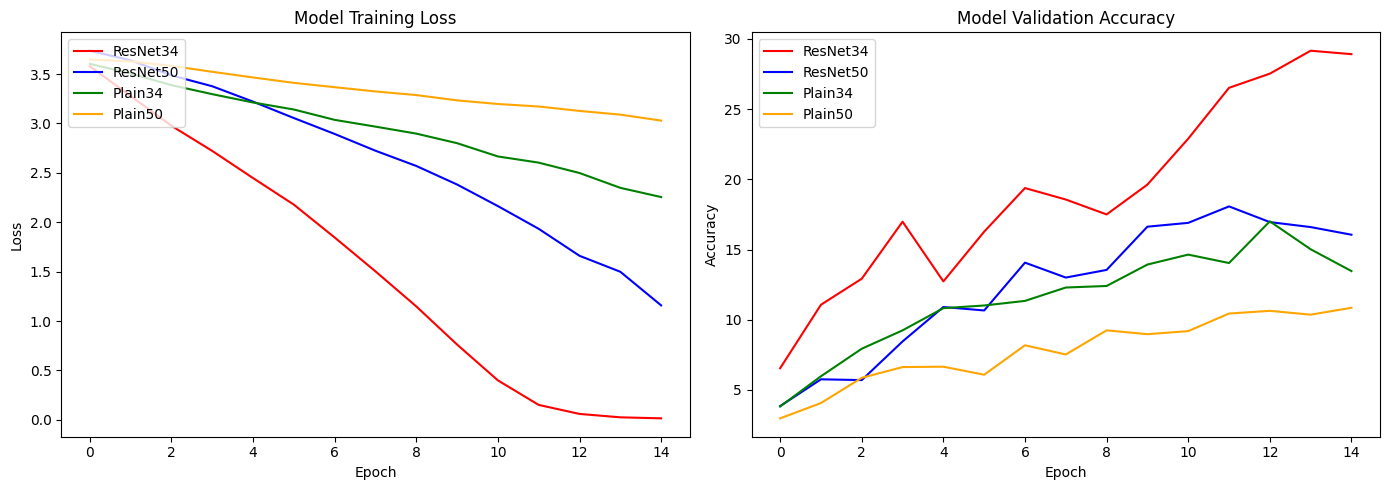

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(resnet_34_train_losses, 'r', label="ResNet34")
axes[0].plot(resnet_50_train_losses, 'b', label="ResNet50")
axes[0].plot(plain_34_train_losses, 'g', label="Plain34")
axes[0].plot(plain_50_train_losses, 'orange', label="Plain50")
axes[0].set_title('Model Training Loss')
axes[0].set_ylabel('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend(loc='upper left')

# Accuracy
axes[1].plot(resnet_34_val_accuracy, 'r', label="ResNet34")
axes[1].plot(resnet_50_val_accuracy, 'b', label="ResNet50")
axes[1].plot(plain_34_val_accuracy, 'g', label="Plain34")
axes[1].plot(plain_50_val_accuracy, 'orange', label="Plain50")
axes[1].set_title('Model Validation Accuracy')
axes[1].set_ylabel('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend(loc='upper left')

plt.tight_layout()
plt.show()

# 6. 문제점 파악하기
- ResNet34 : 과적합
- ResNet50 : 데이터에 비해 모델이 복잡해서 학습이 제대로 이루어지지 않음
- Plain34 : 같은 깊이의 ResNet34와 비교해 성능이 월등히 떨어짐
- Plain50 : 가장 성능이 좋지 못함

-> ResNet34가 해당 데이터셋에서 가장 적합한 모델이라 판단되며 과적합을 해결하기 위해 Augmentation 과정이 필요할 것으로 판단됨

# 7. 데이터셋 수정하기

- Augmentation

In [37]:
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# test는 증강 없이 Resize만 수행
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Train (train_transform 적용)
trainset = torchvision.datasets.OxfordIIITPet(
    root=data_root,
    split="trainval",
    target_types="category",
    download=True,
    transform=train_transform
)

# Test (test_transform 적용)
testset = torchvision.datasets.OxfordIIITPet(
    root=data_root,
    split="test",
    target_types="category",
    download=True,
    transform=test_transform
)

trainloader = torch.utils.data.DataLoader(
    trainset,
    batch_size=32,
    shuffle=True
)

testloader = torch.utils.data.DataLoader(
    testset,
    batch_size=32,
    shuffle=False
)

# 8. 모델 재학습

### ResNet34

In [38]:
BATCH_SIZE = 32
EPOCH = 15
import time

# 학습 시작 시간 저장
current_time = time.time()

# GPU가 있으면 GPU 사용, 없으면 CPU 사용
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ResNet34 모델 불러오기
num_classes = len(trainset.classes)
resnet_34 = build_resnet34(num_classes=num_classes)
resnet_34.to(device)

# 모든 파라미터를 학습하도록 설정
for param in resnet_34.parameters():
    param.requires_grad = True

# 손실 함수와 최적화 함수 정의
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(resnet_34.parameters(),
                      lr=0.001,
                      momentum=0.9,
                      weight_decay=1e-4)

# 학습 결과 저장 리스트
resnet_34_train_losses = []
resnet_34_val_accuracy = []

# Epoch 반복
for epoch in range(EPOCH):

    # 학습 모드
    resnet_34.train()

    running_loss = 0.0
    correct = 0
    total = 0

    # Train 데이터 반복
    for i, (inputs, labels) in enumerate(trainloader, 0):

        # 데이터를 GPU(CPU)로 이동
        inputs, labels = inputs.to(device), labels.to(device)

        # 이전 기울기 초기화
        optimizer.zero_grad()

        # 모델 예측
        outputs = resnet_34(inputs)

        # 손실 계산
        loss = criterion(outputs, labels)

        # 역전파
        loss.backward()

        # 가중치 업데이트
        optimizer.step()

        # Loss 누적
        running_loss += loss.item()

        # 예측 클래스 선택
        _, predicted = torch.max(outputs, 1)

        # 정확도 계산
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        # 100번째 배치마다 Loss 출력
        if i % 100 == 99:
            print(f"[{epoch + 1}, {i + 1:5d}] loss: {running_loss / (i + 1):.3f}")

    # Epoch 평균 Loss
    train_loss = running_loss / len(trainloader)

    # Epoch 학습 정확도
    train_acc = 100 * correct / total

    resnet_34_train_losses.append(train_loss)

    print(f"Epoch {epoch + 1}: Train Accuracy: {train_acc:.2f}%")

    # 평가 모드
    resnet_34.eval()

    correct = 0
    total = 0

    # Validation에서는 기울기 계산 안 함
    with torch.no_grad():

        # Test 데이터 반복
        for inputs, labels in testloader:

            # 데이터를 GPU(CPU)로 이동
            inputs, labels = inputs.to(device), labels.to(device)

            # 모델 예측
            outputs = resnet_34(inputs)

            # 예측 클래스 선택
            _, predicted = torch.max(outputs, 1)

            # 정확도 계산
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    # Validation 정확도
    val_acc = 100 * correct / total
    resnet_34_val_accuracy.append(val_acc)

    print(f"Epoch {epoch + 1}: Validation Accuracy: {val_acc:.2f}%")

print("Finished Training")

# 총 학습 시간 출력
print(time.time() - current_time)

[1,   100] loss: 3.617
Epoch 1: Train Accuracy: 4.59%
Epoch 1: Validation Accuracy: 4.72%
[2,   100] loss: 3.388
Epoch 2: Train Accuracy: 8.45%
Epoch 2: Validation Accuracy: 11.04%
[3,   100] loss: 3.170
Epoch 3: Train Accuracy: 13.07%
Epoch 3: Validation Accuracy: 12.32%
[4,   100] loss: 3.004
Epoch 4: Train Accuracy: 16.74%
Epoch 4: Validation Accuracy: 11.15%
[5,   100] loss: 2.889
Epoch 5: Train Accuracy: 19.32%
Epoch 5: Validation Accuracy: 15.75%
[6,   100] loss: 2.695
Epoch 6: Train Accuracy: 23.80%
Epoch 6: Validation Accuracy: 14.72%
[7,   100] loss: 2.566
Epoch 7: Train Accuracy: 27.53%
Epoch 7: Validation Accuracy: 20.77%
[8,   100] loss: 2.418
Epoch 8: Train Accuracy: 30.38%
Epoch 8: Validation Accuracy: 15.13%
[9,   100] loss: 2.262
Epoch 9: Train Accuracy: 34.13%
Epoch 9: Validation Accuracy: 23.90%
[10,   100] loss: 2.167
Epoch 10: Train Accuracy: 36.47%
Epoch 10: Validation Accuracy: 23.39%
[11,   100] loss: 2.017
Epoch 11: Train Accuracy: 40.54%
Epoch 11: Validation Ac

### ResNet50

In [40]:
BATCH_SIZE = 32
EPOCH = 15

# 학습 시작 시간 저장
current_time = time.time()

# GPU가 있으면 GPU 사용, 없으면 CPU 사용
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ResNet50 모델 불러오기
num_classes = len(trainset.classes)
resnet_50 = build_resnet50(num_classes=num_classes)
resnet_50.to(device)

# 모든 파라미터를 학습하도록 설정
for param in resnet_50.parameters():
    param.requires_grad = True

# 손실 함수와 최적화 함수 정의
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(resnet_50.parameters(),
                      lr=0.001,
                      momentum=0.9,
                      weight_decay=1e-4)

# 학습 결과 저장 리스트
resnet_50_train_losses = []
resnet_50_val_accuracy = []

# Epoch 반복
for epoch in range(EPOCH):

    # 학습 모드
    resnet_50.train()

    running_loss = 0.0
    correct = 0
    total = 0

    # Train 데이터 반복
    for i, (inputs, labels) in enumerate(trainloader, 0):

        # 데이터를 GPU(CPU)로 이동
        inputs, labels = inputs.to(device), labels.to(device)

        # 이전 기울기 초기화
        optimizer.zero_grad()

        # 모델 예측
        outputs = resnet_50(inputs)

        # 손실 계산
        loss = criterion(outputs, labels)

        # 역전파
        loss.backward()

        # 가중치 업데이트
        optimizer.step()

        # Loss 누적
        running_loss += loss.item()

        # 예측 클래스 선택
        _, predicted = torch.max(outputs, 1)

        # 정확도 계산
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        # 100번째 배치마다 Loss 출력
        if i % 100 == 99:
            print(f"[{epoch + 1}, {i + 1:5d}] loss: {running_loss / (i + 1):.3f}")

    # Epoch 평균 Loss
    train_loss = running_loss / len(trainloader)

    # Epoch 학습 정확도
    train_acc = 100 * correct / total

    resnet_50_train_losses.append(train_loss)

    print(f"Epoch {epoch + 1}: Train Accuracy: {train_acc:.2f}%")

    # 평가 모드
    resnet_50.eval()

    correct = 0
    total = 0

    # Validation에서는 기울기 계산 안 함
    with torch.no_grad():

        # Test 데이터 반복
        for inputs, labels in testloader:

            # 데이터를 GPU(CPU)로 이동
            inputs, labels = inputs.to(device), labels.to(device)

            # 모델 예측
            outputs = resnet_50(inputs)

            # 예측 클래스 선택
            _, predicted = torch.max(outputs, 1)

            # 정확도 계산
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    # Validation 정확도
    val_acc = 100 * correct / total
    resnet_50_val_accuracy.append(val_acc)

    print(f"Epoch {epoch + 1}: Validation Accuracy: {val_acc:.2f}%")

print("Finished Training")

# 총 학습 시간 출력
print(time.time() - current_time)

[1,   100] loss: 3.770
Epoch 1: Train Accuracy: 3.32%
Epoch 1: Validation Accuracy: 3.46%
[2,   100] loss: 3.631
Epoch 2: Train Accuracy: 5.03%
Epoch 2: Validation Accuracy: 5.04%
[3,   100] loss: 3.560
Epoch 3: Train Accuracy: 6.66%
Epoch 3: Validation Accuracy: 7.25%
[4,   100] loss: 3.444
Epoch 4: Train Accuracy: 7.72%
Epoch 4: Validation Accuracy: 8.80%
[5,   100] loss: 3.337
Epoch 5: Train Accuracy: 9.95%
Epoch 5: Validation Accuracy: 8.50%
[6,   100] loss: 3.259
Epoch 6: Train Accuracy: 12.20%
Epoch 6: Validation Accuracy: 12.32%
[7,   100] loss: 3.156
Epoch 7: Train Accuracy: 14.27%
Epoch 7: Validation Accuracy: 12.32%
[8,   100] loss: 3.066
Epoch 8: Train Accuracy: 16.30%
Epoch 8: Validation Accuracy: 13.87%
[9,   100] loss: 2.970
Epoch 9: Train Accuracy: 18.29%
Epoch 9: Validation Accuracy: 16.38%
[10,   100] loss: 2.886
Epoch 10: Train Accuracy: 19.92%
Epoch 10: Validation Accuracy: 15.89%
[11,   100] loss: 2.853
Epoch 11: Train Accuracy: 20.95%
Epoch 11: Validation Accuracy:

### Plain34

In [41]:
BATCH_SIZE = 32
EPOCH = 15

# 학습 시작 시간 저장
current_time = time.time()

# GPU가 있으면 GPU 사용, 없으면 CPU 사용
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Plain34 모델 불러오기
num_classes = len(trainset.classes)
plain_34 = build_plain34(num_classes=num_classes)
plain_34.to(device)

# 모든 파라미터를 학습하도록 설정
for param in plain_34.parameters():
    param.requires_grad = True

# 손실 함수와 최적화 함수 정의
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(plain_34.parameters(),
                      lr=0.001,
                      momentum=0.9,
                      weight_decay=1e-4)

# 학습 결과 저장 리스트
plain_34_train_losses = []
plain_34_val_accuracy = []

# Epoch 반복
for epoch in range(EPOCH):

    # 학습 모드
    plain_34.train()

    running_loss = 0.0
    correct = 0
    total = 0

    # Train 데이터 반복
    for i, (inputs, labels) in enumerate(trainloader, 0):

        # 데이터를 GPU(CPU)로 이동
        inputs, labels = inputs.to(device), labels.to(device)

        # 이전 기울기 초기화
        optimizer.zero_grad()

        # 모델 예측
        outputs = plain_34(inputs)

        # 손실 계산
        loss = criterion(outputs, labels)

        # 역전파
        loss.backward()

        # 가중치 업데이트
        optimizer.step()

        # Loss 누적
        running_loss += loss.item()

        # 예측 클래스 선택
        _, predicted = torch.max(outputs, 1)

        # 정확도 계산
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        # 100번째 배치마다 Loss 출력
        if i % 100 == 99:
            print(f"[{epoch + 1}, {i + 1:5d}] loss: {running_loss / (i + 1):.3f}")

    # Epoch 평균 Loss
    train_loss = running_loss / len(trainloader)

    # Epoch 학습 정확도
    train_acc = 100 * correct / total

    plain_34_train_losses.append(train_loss)

    print(f"Epoch {epoch + 1}: Train Accuracy: {train_acc:.2f}%")

    # 평가 모드
    plain_34.eval()

    correct = 0
    total = 0

    # Validation에서는 기울기 계산 안 함
    with torch.no_grad():

        # Test 데이터 반복
        for inputs, labels in testloader:

            # 데이터를 GPU(CPU)로 이동
            inputs, labels = inputs.to(device), labels.to(device)

            # 모델 예측
            outputs = plain_34(inputs)

            # 예측 클래스 선택
            _, predicted = torch.max(outputs, 1)

            # 정확도 계산
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    # Validation 정확도
    val_acc = 100 * correct / total
    plain_34_val_accuracy.append(val_acc)

    print(f"Epoch {epoch + 1}: Validation Accuracy: {val_acc:.2f}%")

print("Finished Training")

# 총 학습 시간 출력
print(time.time() - current_time)

[1,   100] loss: 3.615
Epoch 1: Train Accuracy: 3.75%
Epoch 1: Validation Accuracy: 3.60%
[2,   100] loss: 3.550
Epoch 2: Train Accuracy: 5.41%
Epoch 2: Validation Accuracy: 4.50%
[3,   100] loss: 3.469
Epoch 3: Train Accuracy: 6.98%
Epoch 3: Validation Accuracy: 7.58%
[4,   100] loss: 3.403
Epoch 4: Train Accuracy: 7.99%
Epoch 4: Validation Accuracy: 8.72%
[5,   100] loss: 3.319
Epoch 5: Train Accuracy: 10.54%
Epoch 5: Validation Accuracy: 9.05%
[6,   100] loss: 3.249
Epoch 6: Train Accuracy: 11.49%
Epoch 6: Validation Accuracy: 9.78%
[7,   100] loss: 3.195
Epoch 7: Train Accuracy: 12.34%
Epoch 7: Validation Accuracy: 11.86%
[8,   100] loss: 3.120
Epoch 8: Train Accuracy: 14.35%
Epoch 8: Validation Accuracy: 10.82%
[9,   100] loss: 3.057
Epoch 9: Train Accuracy: 14.95%
Epoch 9: Validation Accuracy: 13.76%
[10,   100] loss: 2.992
Epoch 10: Train Accuracy: 15.49%
Epoch 10: Validation Accuracy: 12.86%
[11,   100] loss: 2.952
Epoch 11: Train Accuracy: 16.68%
Epoch 11: Validation Accuracy:

### Plain50

In [42]:
BATCH_SIZE = 32
EPOCH = 15

# 학습 시작 시간 저장
current_time = time.time()

# GPU가 있으면 GPU 사용, 없으면 CPU 사용
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Plain50 모델 불러오기
num_classes = len(trainset.classes)
plain_50 = build_plain50(num_classes=num_classes)
plain_50.to(device)

# 모든 파라미터를 학습하도록 설정
for param in plain_50.parameters():
    param.requires_grad = True

# 손실 함수와 최적화 함수 정의
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(plain_50.parameters(),
                      lr=0.001,
                      momentum=0.9,
                      weight_decay=1e-4)

# 학습 결과 저장 리스트
plain_50_train_losses = []
plain_50_val_accuracy = []

# Epoch 반복
for epoch in range(EPOCH):

    # 학습 모드
    plain_50.train()

    running_loss = 0.0
    correct = 0
    total = 0

    # Train 데이터 반복
    for i, (inputs, labels) in enumerate(trainloader, 0):

        # 데이터를 GPU(CPU)로 이동
        inputs, labels = inputs.to(device), labels.to(device)

        # 이전 기울기 초기화
        optimizer.zero_grad()

        # 모델 예측
        outputs = plain_50(inputs)

        # 손실 계산
        loss = criterion(outputs, labels)

        # 역전파
        loss.backward()

        # 가중치 업데이트
        optimizer.step()

        # Loss 누적
        running_loss += loss.item()

        # 예측 클래스 선택
        _, predicted = torch.max(outputs, 1)

        # 정확도 계산
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        # 100번째 배치마다 Loss 출력
        if i % 100 == 99:
            print(f"[{epoch + 1}, {i + 1:5d}] loss: {running_loss / (i + 1):.3f}")

    # Epoch 평균 Loss
    train_loss = running_loss / len(trainloader)

    # Epoch 학습 정확도
    train_acc = 100 * correct / total

    plain_50_train_losses.append(train_loss)

    print(f"Epoch {epoch + 1}: Train Accuracy: {train_acc:.2f}%")

    # 평가 모드
    plain_50.eval()

    correct = 0
    total = 0

    # Validation에서는 기울기 계산 안 함
    with torch.no_grad():

        # Test 데이터 반복
        for inputs, labels in testloader:

            # 데이터를 GPU(CPU)로 이동
            inputs, labels = inputs.to(device), labels.to(device)

            # 모델 예측
            outputs = plain_50(inputs)

            # 예측 클래스 선택
            _, predicted = torch.max(outputs, 1)

            # 정확도 계산
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    # Validation 정확도
    val_acc = 100 * correct / total
    plain_50_val_accuracy.append(val_acc)

    print(f"Epoch {epoch + 1}: Validation Accuracy: {val_acc:.2f}%")

print("Finished Training")

# 총 학습 시간 출력
print(time.time() - current_time)

[1,   100] loss: 3.638
Epoch 1: Train Accuracy: 2.34%
Epoch 1: Validation Accuracy: 3.54%
[2,   100] loss: 3.609
Epoch 2: Train Accuracy: 3.72%
Epoch 2: Validation Accuracy: 4.58%
[3,   100] loss: 3.579
Epoch 3: Train Accuracy: 4.32%
Epoch 3: Validation Accuracy: 4.61%
[4,   100] loss: 3.533
Epoch 4: Train Accuracy: 5.30%
Epoch 4: Validation Accuracy: 7.36%
[5,   100] loss: 3.470
Epoch 5: Train Accuracy: 6.85%
Epoch 5: Validation Accuracy: 7.66%
[6,   100] loss: 3.427
Epoch 6: Train Accuracy: 7.72%
Epoch 6: Validation Accuracy: 8.20%
[7,   100] loss: 3.393
Epoch 7: Train Accuracy: 8.32%
Epoch 7: Validation Accuracy: 8.83%
[8,   100] loss: 3.354
Epoch 8: Train Accuracy: 8.45%
Epoch 8: Validation Accuracy: 9.21%
[9,   100] loss: 3.315
Epoch 9: Train Accuracy: 9.54%
Epoch 9: Validation Accuracy: 9.70%
[10,   100] loss: 3.253
Epoch 10: Train Accuracy: 9.95%
Epoch 10: Validation Accuracy: 10.58%
[11,   100] loss: 3.240
Epoch 11: Train Accuracy: 11.14%
Epoch 11: Validation Accuracy: 11.15%
[

# 9. 결과 시각화

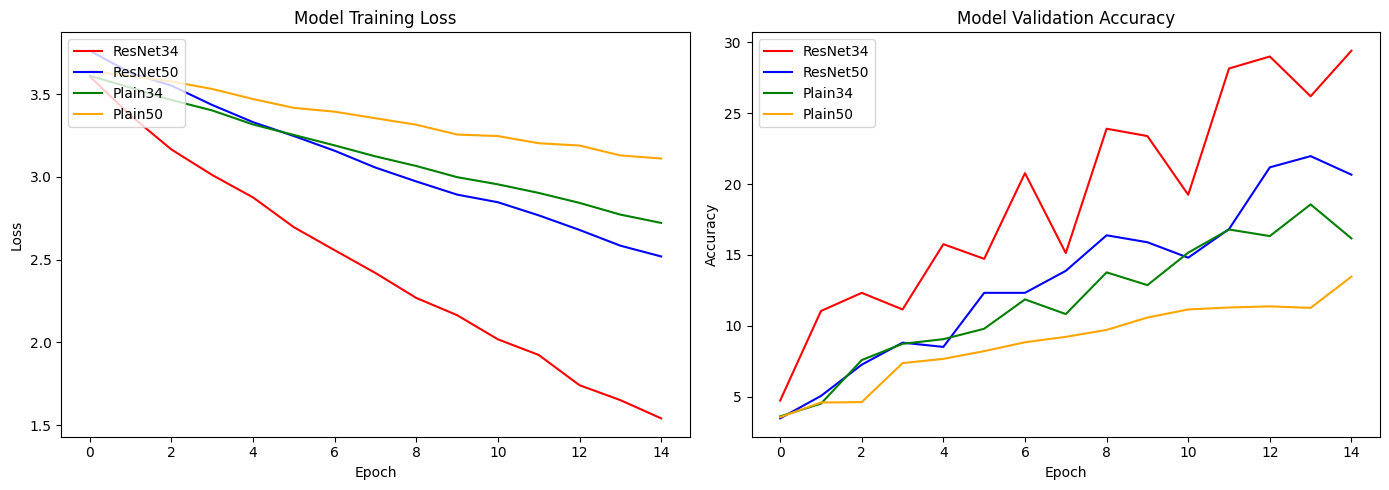

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(resnet_34_train_losses, 'r', label="ResNet34")
axes[0].plot(resnet_50_train_losses, 'b', label="ResNet50")
axes[0].plot(plain_34_train_losses, 'g', label="Plain34")
axes[0].plot(plain_50_train_losses, 'orange', label="Plain50")
axes[0].set_title('Model Training Loss')
axes[0].set_ylabel('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend(loc='upper left')

# Accuracy
axes[1].plot(resnet_34_val_accuracy, 'r', label="ResNet34")
axes[1].plot(resnet_50_val_accuracy, 'b', label="ResNet50")
axes[1].plot(plain_34_val_accuracy, 'g', label="Plain34")
axes[1].plot(plain_50_val_accuracy, 'orange', label="Plain50")
axes[1].set_title('Model Validation Accuracy')
axes[1].set_ylabel('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend(loc='upper left')

plt.tight_layout()
plt.show()

# 10. Ablation Study 결과표

| 모델       | Data Aug. | Train Acc.(%) | Best Val. Acc.(%) | 학습시간(s) |
| -------- | :-------: | ------------: | ----------------: | ------: |
| ResNet34 |     X     |    **100.00** |             29.16 |     959 |
| ResNet34 |     O     |         53.86 |         **29.41** |    1118 |
| ResNet50 |     X     |         66.20 |             18.07 |    1279 |
| ResNet50 |     O     |         29.16 |         **21.97** |    1398 |
| Plain34  |     X     |         36.58 |             17.01 |     960 |
| Plain34  |     O     |         22.23 |         **18.56** |    1093 |
| Plain50  |     X     |         15.73 |             10.85 |    1221 |
| Plain50  |     O     |         13.04 |         **13.46** |    1289 |


- 데이터 증강을 통해 ResNet34의 과적합이 완화되었음을 확인함
- 에포크를 늘리면 더 좋은 성능이 나올 것으로 기대됨

# 배운점
- 데이터 분석의 중요성
- 데이터셋에 적합한 모델을(모델에 적합한 데이터셋을) 사용해야 한다는 점
- 이번 비교 실험처럼 단순한 데이터셋에 복잡한 모델을 이용하면 학습이 제대로 이루어지지 않음